# Schelling Segregation Model

* extended by the choice of perception neighbourhood
* extended by the perception radius

In [5]:
def step(self):
        similar = 0
        all = 0
        
        for neighbor in self.model.grid.iter_neighbors(self.pos, moore=self.model.perception_moore,
                                                       radius = self.model.perception_radius):
            all +=1
            if neighbor.type == self.type:
                similar += 1

        # If unhappy, move:
        if all == 0 or similar/all < self.model.homophily:
            self.model.grid.move_to_empty(self)
        else:
            self.model.happy += 1

In [15]:
import mesa
import sys
sys.path.insert(0,'/daten/INES/Lehre/ABM/Code/git/mesa/examples/schelling')
from model import Schelling

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec
from matplotlib.colors import LinearSegmentedColormap

%matplotlib inline

## Helper functions

In [2]:
uniks = LinearSegmentedColormap.from_list( 'unik', [np.array((80,149,200))/255, np.array((74,172,150))/255,
                                                  np.array((234,195,114))/255, np.array((199,16,92))/255])

def draw_grid(model, ax=None):
    """
    Draw the current state of the grid, with agents of the minority (type 1) in red
    and agents of type 2 in blue.
    """
    if not ax:
        fig, ax = plt.subplots(figsize=(6, 6))
    grid = np.zeros((model.grid.width, model.grid.height))
    for agent, x, y in model.grid.coord_iter():
        if agent is not None :
            grid[y][x] = agent.type
    ax.pcolormesh(grid, cmap=uniks, vmin=0, vmax=1)
    ax.axis("off")
    ax.set_title("Steps: {}".format(model.schedule.steps))

In [3]:
def run_model(model, steps = [10,10,20,20,40]):
    """
    Run an experiment with a given model, and plot the results.
    """
    fig = plt.figure(figsize=(12, 8))

    for i in range(0, len(steps)):
        ax = fig.add_subplot(331 + i)
        draw_grid(model, ax)
        model.run(steps[i])
        
    ax = fig.add_subplot(331 + i + 1)
    draw_grid(model, ax)    
    
    ax = fig.add_subplot(313)

    d = model.datacollector.get_model_vars_dataframe()
    d = d * 100 / model.schedule.get_agent_count()
    d.plot(ax=ax, colormap=uniks)
    

In [4]:
def plot_effect(data, valuename="happy", valuelabel="Happiness"):
    plot_df = (data.reset_index().pivot(index='perception_neighbourhood', columns='perception_radius'))[valuename]

    fig, ax = plt.subplots()
    im = ax.imshow(plot_df)
    plt.colorbar(im)
    plt.xlabel('Perception radius')
    plt.ylabel('Perception neighbourhood')
    plt.title(valuelabel)
    ax.set_xticks(np.arange(plot_df.shape[1]))
    ax.set_xticklabels(plot_df.columns.values)
    ax.set_yticks(np.arange(plot_df.shape[0]))
    ax.set_yticklabels(plot_df.index)

## Different perceptions of neighbourhood

### Inspect single model run

Running Mesa INES's Model...


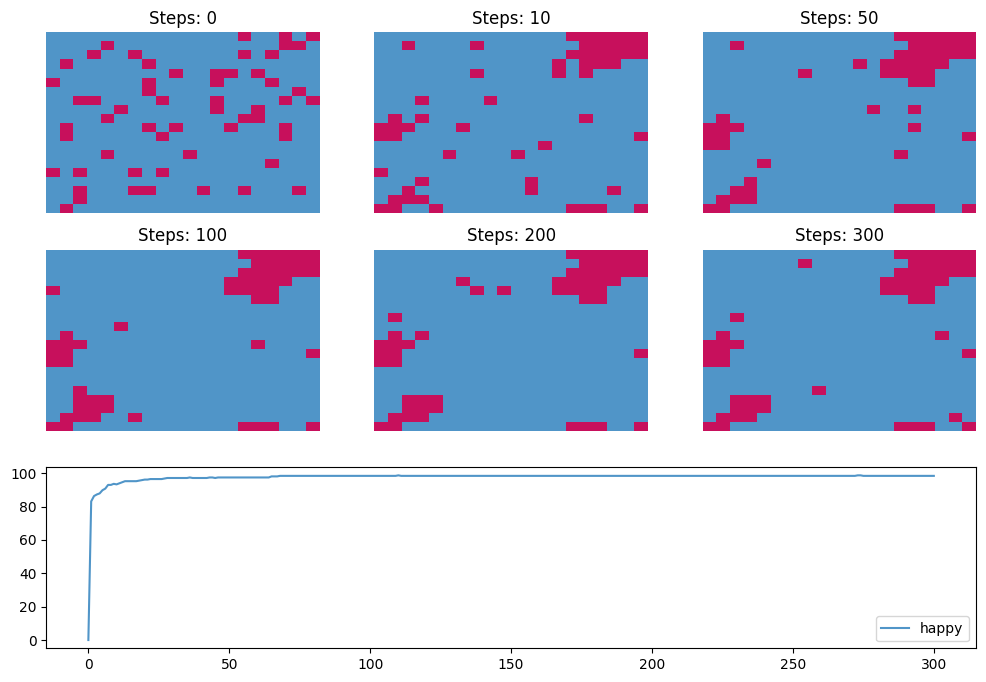

In [23]:
model = Schelling(width = 20,
    height = 20,
    density=0.8,
    minority_pc=0.2,
    homophily=3/8,
    perception_neighbourhood = "Moore",
    perception_radius = 1)
run_model(model, steps = [10,40,50,100,100])

Running Mesa INES's Model...


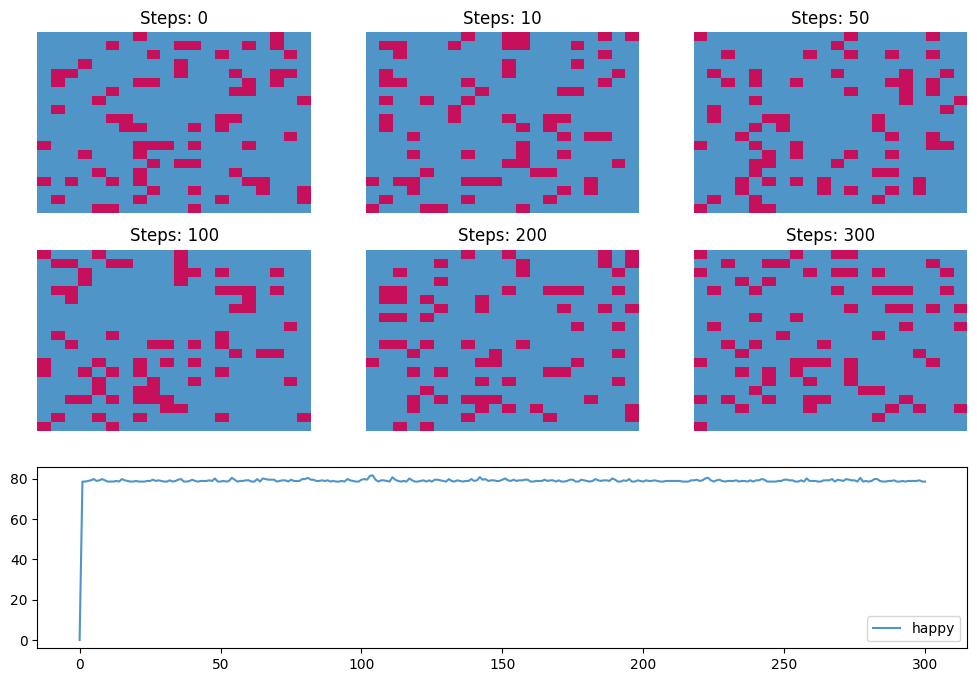

In [24]:
model = Schelling(width = 20,
    height = 20,
    density=0.8,
    minority_pc=0.2,
    homophily=3/8,
    perception_neighbourhood = "Moore",
    perception_radius = 2)
run_model(model, steps = [10,40,50,100,100])

### Batch runs

In [5]:
import numpy as np
from mesa.batchrunner import batch_run
from IPython.utils import io

params = dict(
    width = 20,
    height = 20,
    density=0.8,
    minority_pc=0.2,
    homophily=3/8,
    perception_neighbourhood = {"Moore","VonNeumann"},
    perception_radius = {1,2,3}
)

with io.capture_output() as captured:
    results = batch_run(
            Schelling,
            parameters=params,
            data_collection_period = -1,
            iterations = 100,
            max_steps = 200,
        )

In [6]:
pd.DataFrame(results)
data = pd.DataFrame(results)[['perception_neighbourhood', 'perception_radius', 'iteration', 'happy', 'Step']].round(decimals=1)
data = data.groupby(['perception_neighbourhood', 'perception_radius']).agg(np.mean)

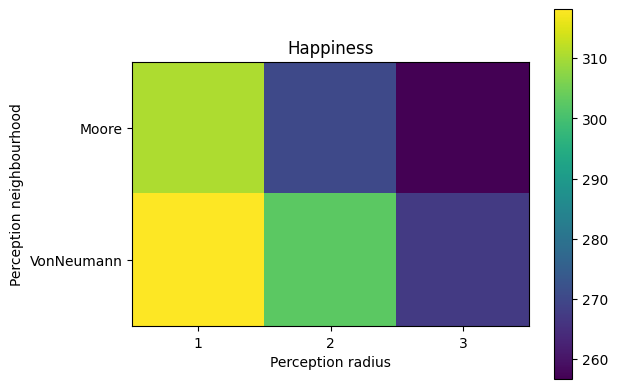

In [7]:
plot_effect(data, valuename="happy", valuelabel="Happiness")

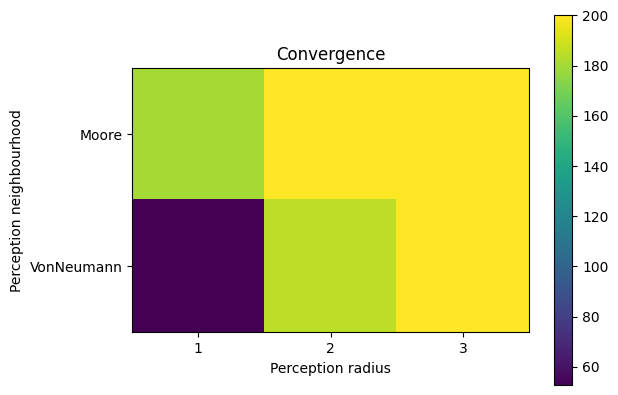

In [8]:
plot_effect(data, valuename="Step", valuelabel="Convergence")

# Run Schelling in browser

In [ ]:
from server import server
server.launch()